✅ Dados carregados com sucesso!
📋 Total de registros: 10 | Total de colunas: 9

📊 Resumo estatístico:
       id_cliente  valor_mensal  dias_uso_ultimo_mes  chamados_suporte  \
count       10.00         10.00                10.00             10.00   
mean         5.50        109.90                15.40              2.20   
std          3.03         65.83                 8.26              1.75   
min          1.00         49.90                 5.00              0.00   
25%          3.25         49.90                 8.50              1.00   
50%          5.50         99.90                15.00              2.00   
75%          7.75        174.90                21.50              3.75   
max         10.00        199.90                28.00              5.00   

       funcionalidades_usadas    nps  meses_de_contrato  churn  
count                   10.00  10.00              10.00  10.00  
mean                     3.90   6.30              12.70   0.40  
std                      2.51   2.75

/tmp/ipykernel_3218/1345824696.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="churn", y="dias_uso_ultimo_mes", data=dados, palette=["#27ae60", "#c0392b"])


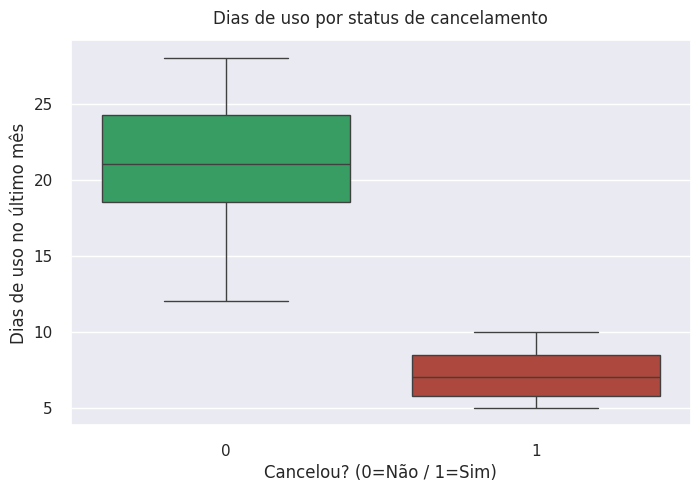

/tmp/ipykernel_3218/1345824696.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="churn", y="chamados_suporte", data=dados, palette=["#27ae60", "#c0392b"])


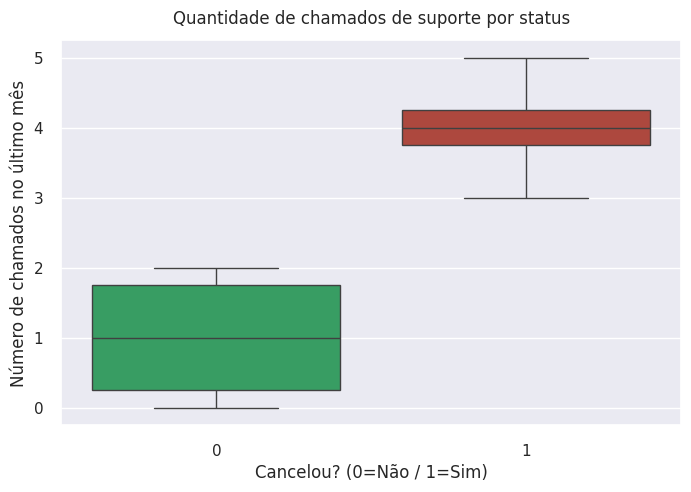


✅ DESEMPENHO DO MODELO:
--------------------------------------------------
Acurácia: 66.7%

Relatório de classificação:
              precision    recall  f1-score   support

Não cancelou       1.00      0.50      0.67         2
    Cancelou       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3


🔍 Risco estimado de cancelamento: 100.0%


In [15]:
# ==============================================
# 📊 PROJETO: PREVISÃO DE CHURN EM CLIENTES SAAS
# Autor: Rodrigo M G Morais
# Repositório: https://github.com/RodrigoMGMorais/SaaS-Churn-Predictive-Architecture
# ==============================================

# 🔹 Importar todas as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 🎨 Configuração visual dos gráficos
plt.style.use('seaborn-v0_8')
sns.set(font_scale=1)

# ==============================================
# 📥 ETAPA 1: CARREGAR DADOS
# ==============================================
url = "https://raw.githubusercontent.com/RodrigoMGMorais/SaaS-Churn-Predictive-Architecture/main/01_Conceitos_e_Indicadores/dados_exemplo.csv"
dados = pd.read_csv(url, sep=",", encoding="utf-8", engine="python")

print("✅ Dados carregados com sucesso!")
print(f"📋 Total de registros: {dados.shape[0]} | Total de colunas: {dados.shape[1]}")

# ==============================================
# 📊 ETAPA 2: ANÁLISE EXPLORATÓRIA
# ==============================================
print("\n📊 Resumo estatístico:")
print(dados.describe().round(2))

print("\n📊 Quantidade de clientes por situação:")
print(dados["churn"].value_counts().rename({0: "Não cancelou", 1: "Cancelou"}))

# Gráfico 1: Dias de uso vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x="churn", y="dias_uso_ultimo_mes", data=dados, palette=["#27ae60", "#c0392b"])
plt.title("Dias de uso por status de cancelamento", pad=12)
plt.xlabel("Cancelou? (0=Não / 1=Sim)")
plt.ylabel("Dias de uso no último mês")
plt.show()

# Gráfico 2: Chamados de suporte vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x="churn", y="chamados_suporte", data=dados, palette=["#27ae60", "#c0392b"])
plt.title("Quantidade de chamados de suporte por status", pad=12)
plt.xlabel("Cancelou? (0=Não / 1=Sim)")
plt.ylabel("Número de chamados no último mês")
plt.show()

# ==============================================
# 🤖 ETAPA 3: MODELO PREDITIVO DE RISCO
# ==============================================
# Selecionar variáveis para análise
variaveis = ["valor_mensal", "dias_uso_ultimo_mes", "chamados_suporte", "funcionalidades_usadas", "nps", "meses_de_contrato"]
X = dados[variaveis]
y = dados["churn"]

# Separar dados para treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=42)

# Treinar modelo
modelo = LogisticRegression(max_iter=200)
modelo.fit(X_treino, y_treino)

# Previsões
y_previsto = modelo.predict(X_teste)

# 📈 Resultados
print("\n✅ DESEMPENHO DO MODELO:")
print("-" * 50)
print(f"Acurácia: {accuracy_score(y_teste, y_previsto)*100:.1f}%")
print("\nRelatório de classificação:")
print(classification_report(y_teste, y_previsto, target_names=["Não cancelou", "Cancelou"]))

# 📌 Exemplo prático: Calcular risco para um cliente
novo_cliente = pd.DataFrame({
    "valor_mensal": [49.90],
    "dias_uso_ultimo_mes": [6],
    "chamados_suporte": [4],
    "funcionalidades_usadas": [1],
    "nps": [3],
    "meses_de_contrato": [4]
})

risco = modelo.predict_proba(novo_cliente)[0][1] * 100
print(f"\n🔍 Risco estimado de cancelamento: {risco:.1f}%")